In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("ok")

ok


In [3]:
df = pd.read_csv("../data/telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Clean TotalCharges (this dataset often has blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows where conversion failed
df = df.dropna(subset=["TotalCharges"]).copy()

# Create numeric churn flag
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})

df.shape

(7032, 22)

In [5]:
churn_rate = df["ChurnFlag"].mean()
print(f"Churn rate: {churn_rate:.2%}")

Churn rate: 26.58%


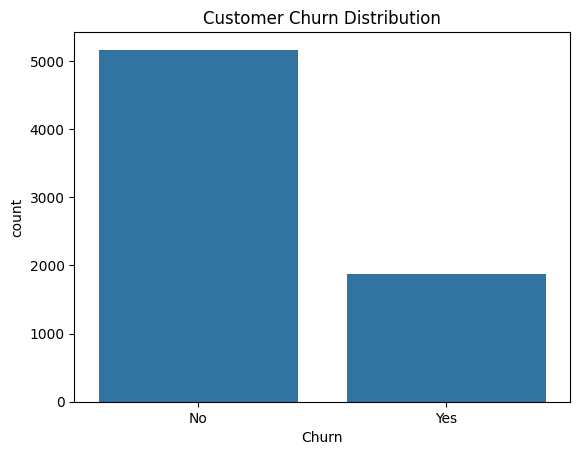

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x="Churn", data=df)
ax.set_title("Customer Churn Distribution")

plt.savefig("../outputs/figures/churn_distribution.png", bbox_inches="tight", dpi=200)
plt.show()

In [7]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .agg(churn_rate="mean", customers="size")
      .sort_values("churn_rate", ascending=False)
)

contract_churn

,churn_rate,customers
Contract,,
Month-to-month,0.427097,3875
One year,0.112772,1472
Two year,0.028487,1685


In [8]:
# Revenue at risk from churned customers
revenue_at_risk = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print(f"Monthly revenue at risk: ${revenue_at_risk:,.2f}")

Monthly revenue at risk: $139,130.85


In [9]:
# Revenue at risk by contract type
revenue_by_contract = (
    df[df["Churn"] == "Yes"]
    .groupby("Contract")["MonthlyCharges"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_contract

Contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: MonthlyCharges, dtype: float64

In [10]:
# Create tenure buckets
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 yr", "1-2 yr", "2-4 yr", "4-6 yr"]
)

tenure_churn = (
    df.groupby("tenure_group")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

tenure_churn

tenure_group
0-1 yr    0.476782
1-2 yr    0.287109
2-4 yr    0.203890
4-6 yr    0.095132
Name: ChurnFlag, dtype: float64

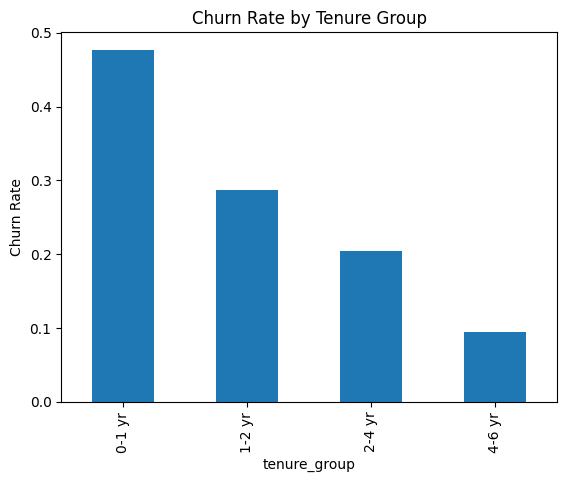

In [11]:
ax = tenure_churn.plot(kind="bar")
ax.set_title("Churn Rate by Tenure Group")
ax.set_ylabel("Churn Rate")

plt.savefig("../outputs/figures/churn_by_tenure.png", dpi=200, bbox_inches="tight")
plt.show()